## Problem 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definite 3 functions
def f1(x:np.arange) -> np.arange:
    return 1/(1+25*x**2)

def f2(x:np.arange) -> np.arange:
    return np.abs(x)

def f3(x: np.ndarray) -> np.ndarray:
    return np.where(x >= 0.25, 1, 0)

def chebyshev_nodes(p):
    k = np.arange(p + 1)
    x = np.cos((2*k + 1) * np.pi / (2*(p + 1)))
    return x

def lagrange(x_nodes, y_nodes, x):
    n = len(x_nodes)
    g = np.zeros_like(x)

    for i in range(n):
        L = np.ones_like(x)
        for j in range(n):
            if j != i:
                L *= (x-x_nodes[j])/(x_nodes[i]-x_nodes[j])
        g += y_nodes[i]*L

    return g

In [4]:
# Compute the Lagrangian polynomials
p_values = [10,20,40]

L1, L2, L3 = [], [], []

x = np.linspace(-1,1,1000)

for p in p_values:

    x_int = chebyshev_nodes(p+1)

    y1 = f1(x_int)
    y2 = f2(x_int)
    y3 = f3(x_int)

    K1 = lagrange(x_int, y1, x)
    K2 = lagrange(x_int, y2, x)
    K3 = lagrange(x_int, y3, x)

    L1.append(K1)
    L2.append(K2)
    L3.append(K3)

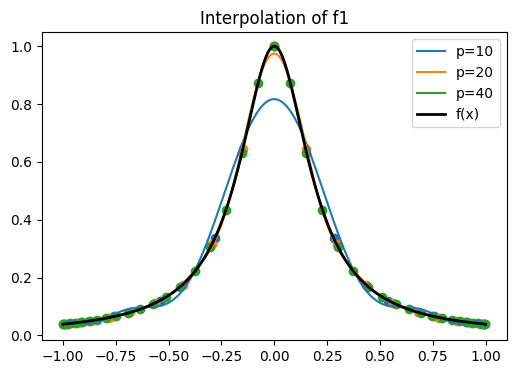

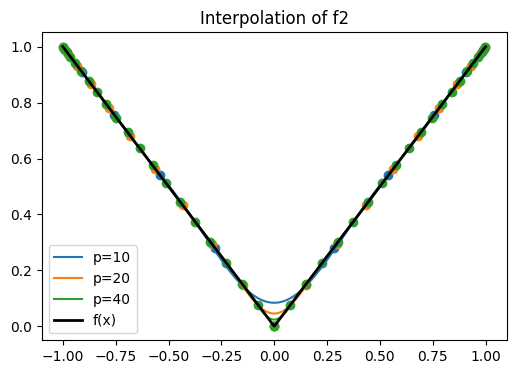

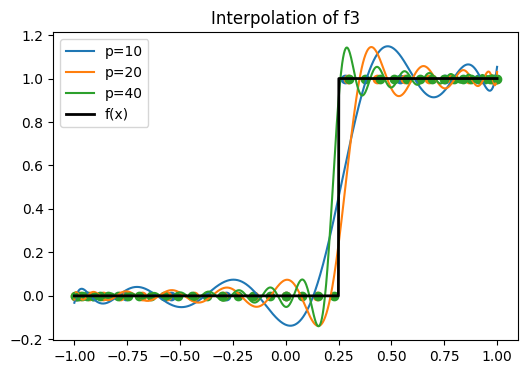

In [5]:
# Visualization

plt.figure(figsize=(6,4))

for i,p in enumerate(p_values):

    x_int = chebyshev_nodes(p)
    plt.plot(x, L1[i], label=f"p={p}")
    plt.scatter(x_int, f1(x_int))

plt.plot(x, f1(x), 'k', linewidth=2, label="f(x)")
plt.title("Interpolation of f1")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))

for i,p in enumerate(p_values):

    x_int = chebyshev_nodes(p)
    plt.plot(x, L2[i], label=f"p={p}")
    plt.scatter(x_int, f2(x_int))

plt.plot(x, f2(x), 'k', linewidth=2, label="f(x)")
plt.title("Interpolation of f2")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))

for i,p in enumerate(p_values):

    x_int = chebyshev_nodes(p)
    plt.plot(x, L3[i], label=f"p={p}")
    plt.scatter(x_int, f3(x_int))

plt.plot(x, f3(x), 'k', linewidth=2, label="f(x)")
plt.title("Interpolation of f3")
plt.legend()
plt.show()

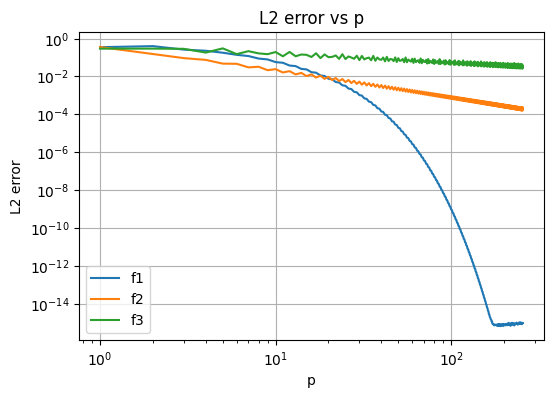

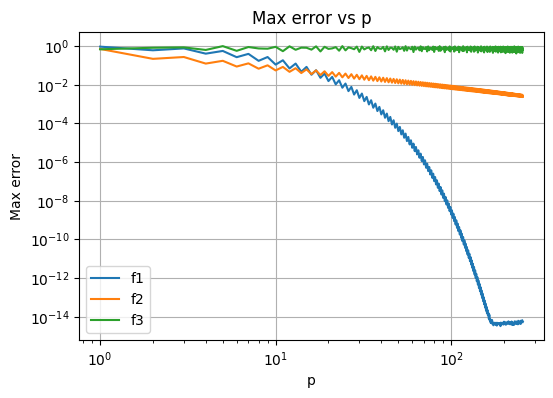

In [ ]:
p_values = np.arange(1,257)

L2_f1 = []
Max_f1 = []

L2_f2 = []
Max_f2 = []

L2_f3 = []
Max_f3 = []

x = np.linspace(-1,1,1000)

for p in p_values:

    x_nodes = chebyshev_nodes(p+1)

    # function values at nodes
    y1 = f1(x_nodes)
    y2 = f2(x_nodes)
    y3 = f3(x_nodes)

    # interpolation
    g1 = lagrange(x_nodes,y1,x)
    g2 = lagrange(x_nodes,y2,x)
    g3 = lagrange(x_nodes,y3,x)

    # true values
    f1_vals = f1(x)
    f2_vals = f2(x)
    f3_vals = f3(x)

    # L2 error
    L2_f1.append(np.sqrt(np.mean((g1-f1_vals)**2)))
    L2_f2.append(np.sqrt(np.mean((g2-f2_vals)**2)))
    L2_f3.append(np.sqrt(np.mean((g3-f3_vals)**2)))

    # Max error
    Max_f1.append(np.max(np.abs(g1-f1_vals)))
    Max_f2.append(np.max(np.abs(g2-f2_vals)))
    Max_f3.append(np.max(np.abs(g3-f3_vals)))

# Plot the L2-error
plt.figure(figsize=(6,4))

plt.loglog(p_values, L2_f1, label="f1")
plt.loglog(p_values, L2_f2, label="f2")
plt.loglog(p_values, L2_f3, label="f3")

plt.xlabel("p")
plt.ylabel("L2 error")
plt.title("L2 error vs p")
plt.legend()
plt.grid(True)

plt.show()

# Plot the Max error
plt.figure(figsize=(6,4))

plt.loglog(p_values, Max_f1, label="f1")
plt.loglog(p_values, Max_f2, label="f2")
plt.loglog(p_values, Max_f3, label="f3")

plt.xlabel("p")
plt.ylabel("Max error")
plt.title("Max error vs p")
plt.legend()
plt.grid(True)

plt.show()

We can notice that as p went up, in both Max error and L2-error criterion, for the smooth function f1, the interpolation error decreases very rapidly with increasing polynomial degree and hit the boundary of machine accuracy. 

The interpolation error depends on the (N+1)-th derivative of the function and on the position of the interpolation points. Chebyshev nodes minimize the interpolation error by controlling the growth of the Lebesgue constant and distributing more points near the edges.  

## Problem 2

In [7]:
## Write the numerical calculator
import numpy as np
from numpy.polynomial.legendre import leggauss, legder, legval

def transform_nodes(nodes,a,b):
    return (b-a)/2 * nodes + (a+b)/2

def Integrate_Gaussian(f, N, a, b):

    nodes, weights = leggauss(5)
    h = (b - a) / N
    Int = 0
    for k in range(N):
        s = a + k*h
        e = a + (k+1)*h
        # map nodes to [s,e]
        x = (e - s)/2 * nodes + (s + e)/2
        # map weights
        w = (e - s)/2 * weights
        for j in range(5):
            Int += w[j] * f(x[j])
    return Int

In [8]:
## Calculate each function
def f1(x):
    return x**8

def f2(x):
    return (np.abs(x - 1/(2**(1/2))))**3

def f3(x):
    return np.where(x >= (1-1/(2**0.5)), 1, 0)

def f4(x):
    return 1/x**0.5

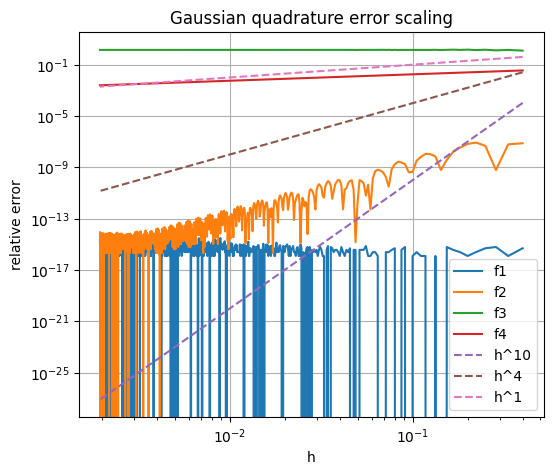

In [10]:
I1 = []
I2 = []
I3 = []
I4 = []
I1_exact = 2/9
I2_exact = ( (1+1/np.sqrt(2))**4 + (1-1/np.sqrt(2))**4 )/4
I3_exact = 1 - 1/np.sqrt(2)
I4_exact = 2

N_values = np.arange(5,1025)

err1 = []
err2 = []
err3 = []
err4 = []

h_vals = []

for N in N_values:

    h = 2/N
    h_vals.append(h)

    F1 = Integrate_Gaussian(f1, N, -1, 1)
    F2 = Integrate_Gaussian(f2, N, -1, 1)
    F3 = Integrate_Gaussian(f3, N, -1, 1)
    F4 = Integrate_Gaussian(f4, N, 0, 1)

    err1.append(abs(F1 - I1_exact)/abs(I1_exact))
    err2.append(abs(F2 - I2_exact)/abs(I2_exact))
    err3.append(abs(F3 - I3_exact)/abs(I3_exact))
    err4.append(abs(F4 - I4_exact)/abs(I4_exact))

plt.figure(figsize=(6,5))

plt.loglog(h_vals, err1, label='f1')
plt.loglog(h_vals, err2, label='f2')
plt.loglog(h_vals, err3, label='f3')
plt.loglog(h_vals, err4, label='f4')

h = np.array(h_vals)

plt.loglog(h, h**10, '--', label='h^10')
plt.loglog(h, h**4, '--', label='h^4')
plt.loglog(h, h**1, '--', label='h^1')

plt.xlabel('h')
plt.ylabel('relative error')
plt.legend()
plt.grid(True)
plt.title('Gaussian quadrature error scaling')
plt.show()

The convergence behavior depends on the smoothness of the integrand.

- $f(x)=x^8$  
  The error is at machine precision because 5-point Gaussian quadrature integrates polynomials exactly up to degree 2n-1=9.

- $f(x)=|x-1/\sqrt{2}|^3$  
  The function is only $C^2$ (the third derivative is discontinuous), so the convergence rate degrades to approximately  
$h^4$

- $f(x)=H(x-1/\sqrt{2})$  
  The function has a jump discontinuity, which prevents high-order convergence. 

- $f(x)=1/\sqrt{x}$  
  The integrand has an endpoint singularity at \(x=0\), reducing the convergence rate to approximately  
  $h^{1/2}$

## Problem 3

(a).

We consider each element of $T_{\alpha}v_m$, which is a $N \times 1$ vector. for the $t^{th}$ element of the multiplication.
Then we have 
$$
\alpha * cos(\frac{2 \pi m(t-1)}{N}) - cos(\frac{2 \pi m(t-2)}{N}) - cos(\frac{2 \pi m(t+1)}{N}) \
= \lambda_{m} cos(\frac{2 \pi m(t-1)}{N})
$$
then we combine all the element together we have $T_{\alpha}v_m = \lambda_{m} v_m$, which shows that $v_m$ is egenvectors of the $T_{\alpha}$.


(b).

When $\alpha > 2$, we have $\alpha > \sum^{1,...,N}_{m \not= i} T_mi = 2$, thus the matrix $T_{m}$ is stricly diagonally dominant which make it a postively definite matrix. 

(c).

We notice that the spectral radius of the Jacobi iteration scheme for matrix is the maximum absolute value of all the egenvalue of the matrix. 

Since from the problem 1 we found that the egenvalue of the $T_{\alpha}$ is $\alpha - 2cos(\frac{2 \pi m }{N})$ so the egenvalue of the so the spectral radius will be $|\alpha|+2$

(d)

In [18]:
import numpy as np
N = 100

# Define the matrix T
T = np.zeros((N, N))
for i in range(N):
    T[i,i] = 2
    T[i,(i-1)%N] = -1
    T[i,(i+1)%N] = -1

# Define the matrix L
L = np.zeros((N,N))
for i in range(N):
    for j in range(i):
        if i > 0 and j == i-1:
            L[i,j] = -1
    L[N-1,0] = -1

# Define the matrix U and D
U = np.transpose(L)
D = np.diag(np.full(N,2))

def Iteration(x, b):
    return np.linalg.inv(D) @ (b - (L + U) @ x)




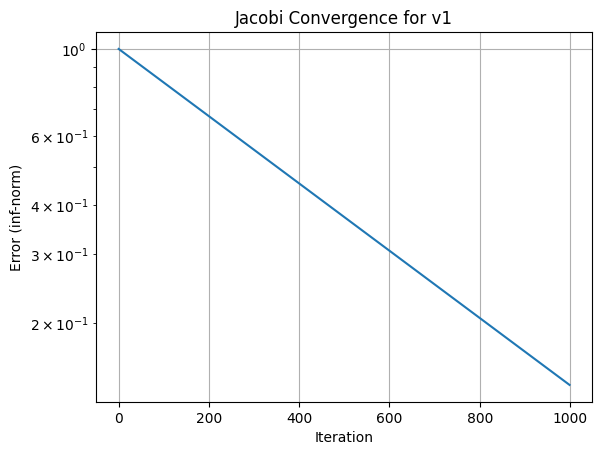

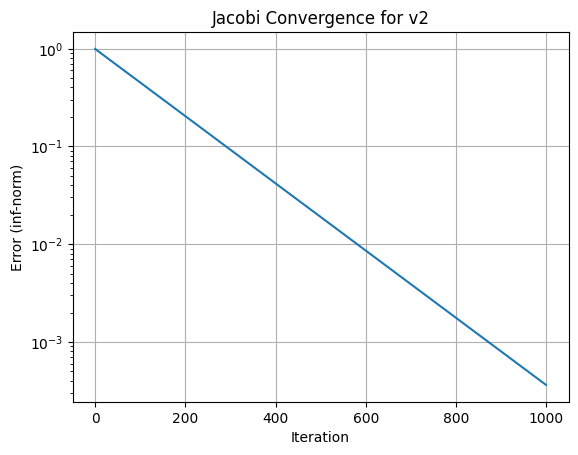

In [23]:
## (1)
#Plot for v_1
n = np.arange(N)
m = 1
vec_true = np.sin(2*np.pi*m*n/N)
lamb = 2 - 2*np.cos(2*np.pi*m/N)
b = lamb * vec_true
errors_1 = []
x = np.zeros(N)

for k in range(1000):
    x = Iteration(x, b)
    e = np.linalg.norm(vec_true - x, np.inf)
    errors_1.append(e)

#Plot for v_2
n = np.arange(N)
m = 2
vec_true = np.sin(2*np.pi*m*n/N)
lamb = 2 - 2*np.cos(2*np.pi*m/N)
b = lamb * vec_true
errors_2 = []
x = np.zeros(N)

for k in range(1000):
    x = Iteration(x, b)
    e = np.linalg.norm(vec_true - x, np.inf)
    errors_2.append(e)

# Visualization
import matplotlib.pyplot as plt
iters = np.arange(len(errors_1))
plt.figure()
plt.plot(iters,errors_1)
plt.xlabel("Iteration")
plt.ylabel("Error (inf-norm)")
plt.title("Jacobi Convergence for v1")

plt.yscale("log") 
plt.grid(True)

plt.show()

iters = np.arange(len(errors_2))
plt.figure()
plt.plot(iters,errors_2)
plt.xlabel("Iteration")
plt.ylabel("Error (inf-norm)")
plt.title("Jacobi Convergence for v2")

plt.yscale("log") 
plt.grid(True)

plt.show()

(2) 
Yes. From the figure we found that the error is geometric convergence, which means iteration number is approximate equal to $log e$ \
When m =1,2 the spectral radius is relatively small, approximate to 1, so we have the equation
$$
e^{(k)} = \rho^k v_m 
$$
thus $log (e^{(k)}) = k log (\rho) v_m $
which is similar to what we observed from the plot. \
Also, since 1<2, $\rho_{2} < \rho_{1}$
thus the speed of convergence 2 is bigger than 1, which also being varified by what we observed from the plot.


(3)
For an arbitrary vector 
$$
y = \sum_{0 \leq m \leq N-1} y_m v_m
$$
the error can be decomposed into Fourier modes. Each mode decays independently with its own convergence factor $\rho_m$. As the iteration proceeds, the components with smaller $|\rho_m|$ decay faster, and the overall convergence rate is dominated by the mode with the largest $|\rho_m|$. Therefore, the convergence rate for an arbitrary vector is determined by the slowest decaying mode, corresponding to the spectral radius of the iteration matrix.
